In [ ]:
!pip install -U scikit-learn imbalanced-learn keras xgboost boruta

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 2.4 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 3.4.1
    Uninstalling keras-3.4.1:
      Successfully uninstalled keras-3.4.1


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier, RandomForestClassifier
from sklearn.linear_model import ElasticNet
from sklearn.metrics import accuracy_score, confusion_matrix
from imblearn.over_sampling import SMOTE
from keras.models import Sequential
from keras.layers import Dense, LSTM
import xgboost as xgb
from boruta import BorutaPy

In [ ]:
df = pd.read_csv('/content/CIC-IDS-2018(15).csv')
df

,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,57610,6,02/03/2018 04:14:05,25,2,0,0,0.0,0,0.0,...,20.0,0.000000,0.000000,0.0,0.0,0.000000e+00,0.000000,0.0,0.0,Benign
1,52347,6,02/03/2018 02:48:44,63,3,1,31,0.0,31,0.0,...,20.0,0.000000,0.000000,0.0,0.0,0.000000e+00,0.000000,0.0,0.0,Benign
2,55970,6,16/02/2018 01:46:19,4217799,5,3,935,350.0,935,0.0,...,32.0,0.000000,0.000000,0.0,0.0,0.000000e+00,0.000000,0.0,0.0,Benign
3,80,6,02/03/2018 05:17:21,54499550,2,0,0,0.0,0,0.0,...,20.0,0.000000,0.000000,0.0,0.0,0.000000e+00,0.000000,0.0,0.0,Benign
4,3389,6,02/03/2018 01:53:13,2697973,9,10,1278,1677.0,677,0.0,...,20.0,0.000000,0.000000,0.0,0.0,0.000000e+00,0.000000,0.0,0.0,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
234115,11395,6,23/02/2018 02:11:10,33,2,0,0,0.0,0,0.0,...,20.0,0.000000,0.000000,0.0,0.0,0.000000e+00,0.000000,0.0,0.0,Benign
234116,63604,6,23/02/2018 08:28:58,93,2,0,0,0.0,0,0.0,...,20.0,0.000000,0.000000,0.0,0.0,0.000000e+00,0.000000,0.0,0.0,Benign
234117,443,6,23/02/2018 11:52:13,60675461,13,12,644,1025.0,366,0.0,...,20.0,25214.333333,33124.892559,92830.0,11577.0,9.995038e+06,20762.677625,10003604.0,9952657.0,Benign
234118,3389,6,23/02/2018 11:15:22,1305556,8,8,1148,1581.0,677,0.0,...,20.0,0.000000,0.000000,0.0,0.0,0.000000e+00,0.000000,0.0,0.0,Benign


In [ ]:
df.dropna(axis=1, how='any', inplace=True)

In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
# Ensure 'Label' column exists before encoding
if 'Label' in df.columns:
    df['Label'] = encoder.fit_transform(df['Label'])

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier, RandomForestClassifier
from sklearn.linear_model import ElasticNet
from sklearn.metrics import accuracy_score, confusion_matrix
from imblearn.over_sampling import SMOTE
from keras.models import Sequential
from keras.layers import Dense, LSTM
import xgboost as xgb
from boruta import BorutaPy

# Load the dataframe
df = pd.read_csv('/content/CIC-IDS-2018(15).csv')

# Instead of dropping all columns with missing values, impute them or drop rows
# For example, to drop rows with any missing values:
df.dropna(axis=0, how='any', inplace=True)
# Or to fill missing values with the mean of the column:
# for column in df.columns:
#     if df[column].isnull().any():
#         df[column].fillna(df[column].mean(), inplace=True)

from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

# Ensure 'Label' column exists before encoding
if 'Label' in df.columns:
    df['Label'] = encoder.fit_transform(df['Label'])

# Now you should be able to drop the 'Label' column
X = df.drop('Label', axis=1)  # Features
y = df['Label']  # Target

<ipython-input-28-fc7ece0c3c18>:16: DtypeWarning: Columns (0,1,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/CIC-IDS-2018(15).csv')


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
X_train['Dst Port'] = pd.to_numeric(X_train['Dst Port'], errors='coerce')
X_test['Dst Port'] = pd.to_numeric(X_test['Dst Port'], errors='coerce')

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
import pandas as pd
from sklearn.pipeline import Pipeline

categorical_features = ['Protocol']
numerical_features = X_train.select_dtypes(include=['number']).columns

X_train['Protocol'] = X_train['Protocol'].astype(str)
X_test['Protocol'] = X_test['Protocol'].astype(str)


numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')), # Impute missing values with mean
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_features), # Use the pipeline for numerical features
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_features) #sparse=False for PCA compatibility
    ])

# Fit and transform the training data
X_train_scaled = preprocessor.fit_transform(X_train)

# Transform the testing data using the same preprocessor
X_test_scaled = preprocessor.transform(X_test)

pca = PCA(n_components=0.95)  # Keep 95% of the variance
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [ ]:
print("\nExplained variance by each PCA component: ")
print(pca.explained_variance_ratio_)


Explained variance by each PCA component: 
[0.76635057 0.22001757]


In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42, k_neighbors=1)
X_train_smote, y_train_smote = smote.fit_resample(X_train_pca, y_train)

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_smote, y_train_smote)

RandomForestClassifier(random_state=42)


Confusion Matrix:
[[84384   193   156     0     0 24462     0    13     0 73485     0]
 [  124  8412     0     0     0     0     0     0     0     2     0]
 [    1     0     5     0     0    15     0     0     0     0     0]
 [    0     0     0     0     0     9     0     0     0     0     0]
 [    0     0     0     0     0  8252     0     0     0     0     0]
 [    0     0     0     0     0  1207     0     0     0     0     0]
 [    0     0     0     0     0 13847     0     0     0     0     0]
 [    0     0     0     0     0     0     0  4164     0     0     0]
 [    0     0     0     0     0   348     0     0     0     0     0]
 [ 1089     5     0     0     0    81     0     2     0  1644     0]
 [    0     0     0     0     0     3     0     0     0     0     0]]


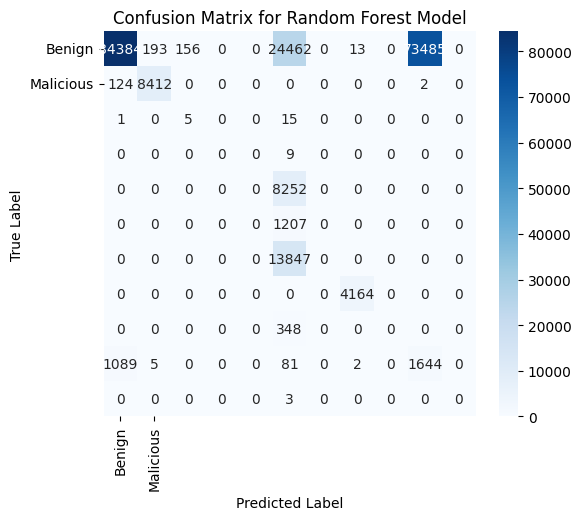

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
y_pred = rf.predict(X_test_pca)
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Visualizing the confusion matrix using heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malicious'], yticklabels=['Benign', 'Malicious'])
plt.title('Confusion Matrix for Random Forest Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


In [ ]:
elastic_net = ElasticNet(alpha=1.0, l1_ratio=0.5)  # l1_ratio=0.5 means equal mix of Lasso and Ridge
elastic_net.fit(X_train_smote, y_train_smote)

ElasticNet()

In [ ]:
y_pred_en = elastic_net.predict(X_test_pca)
y_pred_en_class = [1 if y > 0.5 else 0 for y in y_pred_en]  # Convert regression output to classification
print(f"\nElastic Net Accuracy: {accuracy_score(y_test, y_pred_en_class):.4f}")


Elastic Net Accuracy: 0.0385


In [ ]:
# 2. Recurrent Neural Network (RNN) with LSTM
# Reshape data for LSTM input (RNN expects 3D input)
X_train_rnn = X_train_smote.reshape((X_train_smote.shape[0], X_train_smote.shape[1], 1))
X_test_rnn = X_test_pca.reshape((X_test_pca.shape[0], X_test_pca.shape[1], 1))

In [ ]:
# Create a Sequential RNN model
rnn = Sequential()
rnn.add(LSTM(units=50, return_sequences=True, input_shape=(X_train_rnn.shape[1], 1)))
rnn.add(LSTM(units=50))
rnn.add(Dense(units=1, activation='sigmoid'))  # Sigmoid for binary classification

rnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Train the RNN model
rnn.fit(X_train_rnn, y_train_smote, epochs=5, batch_size=32)

Epoch 1/5
159853/159853 ━━━━━━━━━━━━━━━━━━━━ 819s 5ms/step - accuracy: 0.0838 - loss: -8859.5264
Epoch 2/5
159853/159853 ━━━━━━━━━━━━━━━━━━━━ 823s 5ms/step - accuracy: 0.0834 - loss: -43915.8828
Epoch 3/5
159853/159853 ━━━━━━━━━━━━━━━━━━━━ 836s 5ms/step - accuracy: 0.0832 - loss: -79024.0391
Epoch 4/5
159853/159853 ━━━━━━━━━━━━━━━━━━━━ 827s 5ms/step - accuracy: 0.0834 - loss: -114058.0000
Epoch 5/5
159853/159853 ━━━━━━━━━━━━━━━━━━━━ 801s 5ms/step - accuracy: 0.0833 - loss: -149135.0156


In [ ]:
# Predict and evaluate RNN
y_pred_rnn = (rnn.predict(X_test_rnn) > 0.5).astype(int)
print(f"\nRNN Accuracy: {accuracy_score(y_test, y_pred_rnn):.4f}")

6935/6935 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step

RNN Accuracy: 0.0385


In [ ]:
# 3. Extreme Gradient Boosting (XGBoost)
xgb_model = xgb.XGBClassifier(objective='binary:logistic', n_estimators=100, random_state=42)
xgb_model.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

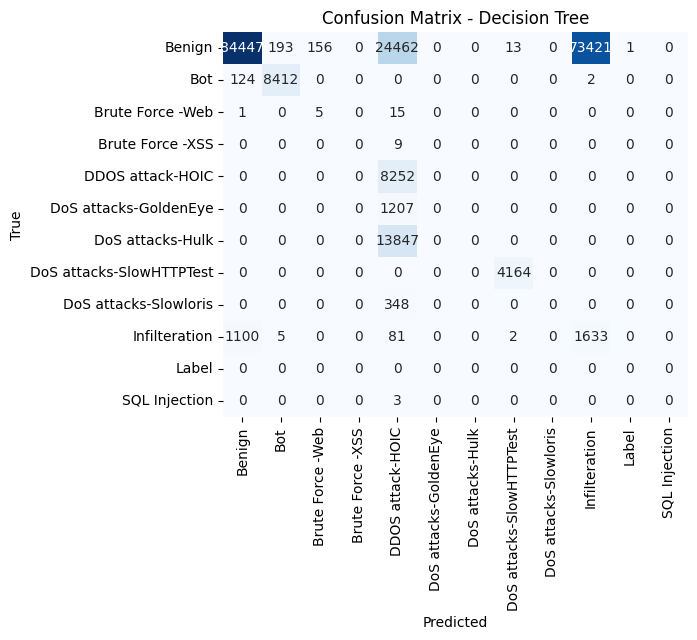

In [ ]:
# Import necessary libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Initialize and train the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_smote, y_train_smote)

# Predict and evaluate the Decision Tree
y_pred_dt = dt_model.predict(X_test_pca)

# 1. Visualize the confusion matrix for Decision Tree
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


**VISUALIZATION**

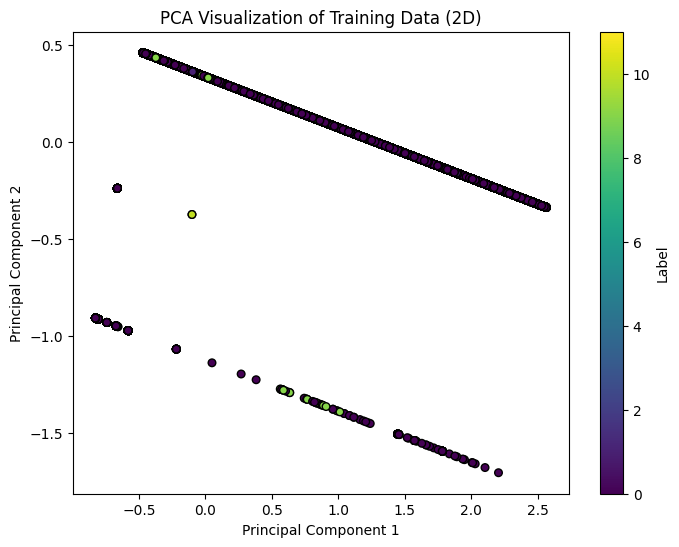

In [ ]:
# PCA Visualization (2D)
plt.figure(figsize=(8, 6))
y_train_smote_reshaped = y_train_smote.values.reshape(-1, 1)

y_train_smote_reshaped = y_train_smote_reshaped.flatten()[:X_train_pca.shape[0]]
# Adjust length to match X_train_pca

plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train_smote_reshaped, cmap='viridis', edgecolor='k', s=30)
plt.title('PCA Visualization of Training Data (2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Label')
plt.show()

Epoch 1/2
127883/127883 ━━━━━━━━━━━━━━━━━━━━ 718s 6ms/step - accuracy: 0.0841 - loss: -7100.2036 - val_accuracy: 0.0832 - val_loss: -28160.5469
Epoch 2/2
127883/127883 ━━━━━━━━━━━━━━━━━━━━ 733s 5ms/step - accuracy: 0.0835 - loss: -35140.9727 - val_accuracy: 0.0832 - val_loss: -56228.5000


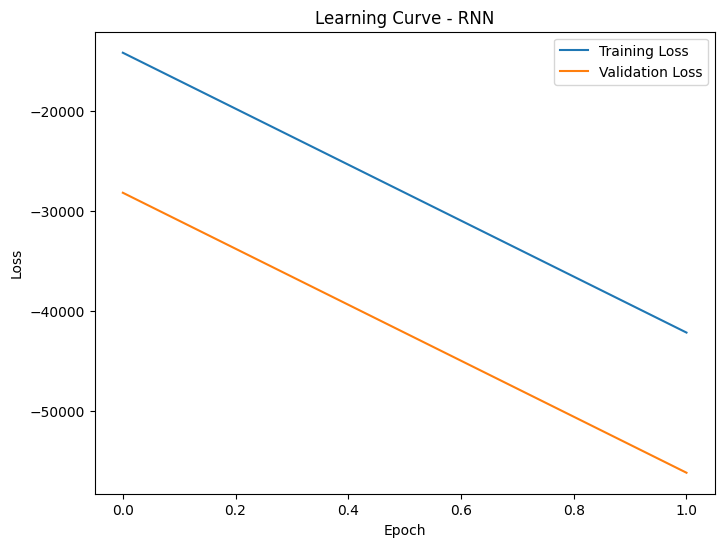

In [ ]:
# Split the data into training and validation sets
X_train_rnn, X_val_rnn, y_train_rnn, y_val_rnn = train_test_split(X_train_smote, y_train_smote, test_size=0.2, random_state=42)

# Reshape data for LSTM input (RNN expects 3D input)
X_train_rnn = X_train_rnn.reshape((X_train_rnn.shape[0], X_train_rnn.shape[1], 1))
X_val_rnn = X_val_rnn.reshape((X_val_rnn.shape[0], X_val_rnn.shape[1], 1))

# Create a Sequential RNN model
rnn = Sequential()
rnn.add(LSTM(units=50, return_sequences=True, input_shape=(X_train_rnn.shape[1], 1)))
rnn.add(LSTM(units=50))
rnn.add(Dense(units=1, activation='sigmoid'))  # Sigmoid for binary classification

rnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the RNN model with validation data
history = rnn.fit(X_train_rnn, y_train_rnn, epochs=2, batch_size=32, validation_data=(X_val_rnn, y_val_rnn))

# Plot the learning curve (training vs validation loss over epochs)
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Learning Curve - RNN')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


Shape of xgb_importance: (2,)
Shape of X_train.columns: (79,)


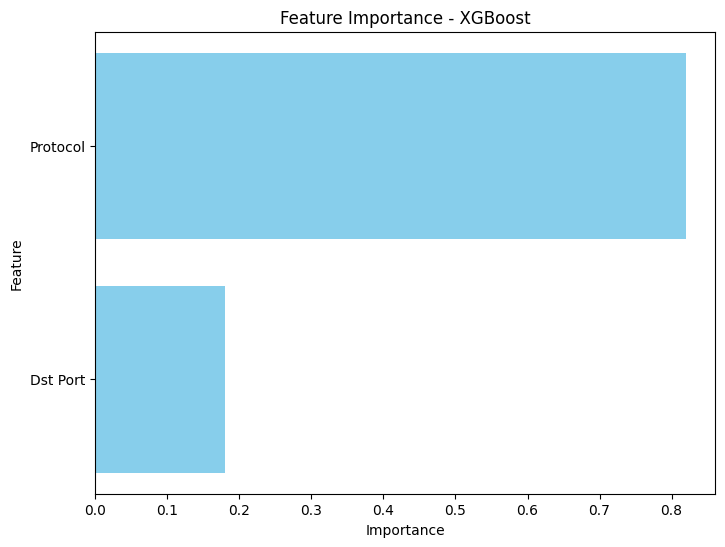

In [ ]:
# Feature Importance for XGBoost
xgb_importance = xgb_model.feature_importances_

# Check the shape of xgb_importance and df.drop('Label', axis=1).columns
print("Shape of xgb_importance:", xgb_importance.shape)
print("Shape of X_train.columns:", X_train.columns.shape)
xgb_feature_names = xgb_model.get_booster().feature_names
if xgb_feature_names is None:
    xgb_feature_names = X_train.columns

xgb_feature_names = xgb_feature_names[:len(xgb_importance)] if len(xgb_feature_names) > len(xgb_importance) else xgb_feature_names

plt.figure(figsize=(8, 6))
plt.barh(xgb_feature_names, xgb_importance, color='skyblue')
plt.title('Feature Importance - XGBoost')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

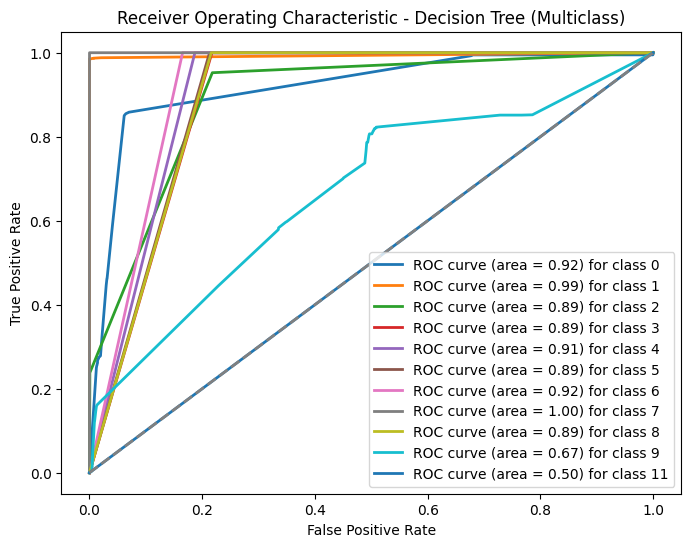

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Binarize the target variable (y_test) for multiclass ROC curve
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))

# Calculate ROC curve for each class
fpr = {}
tpr = {}
roc_auc = {}
for i, class_label in enumerate(np.unique(y_test)):
    fpr[class_label], tpr[class_label], _ = roc_curve(y_test_bin[:, i], dt_model.predict_proba(X_test_pca)[:, i])
    roc_auc[class_label] = auc(fpr[class_label], tpr[class_label])

# Plot ROC curves for each class
plt.figure(figsize=(8, 6))
for i, class_label in enumerate(np.unique(y_test)):
    plt.plot(fpr[class_label], tpr[class_label], lw=2, label=f'ROC curve (area = {roc_auc[class_label]:.2f}) for class {class_label}')

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.title('Receiver Operating Characteristic - Decision Tree (Multiclass)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

from the above visualization we understand the following :

Each colored line represents the ROC curve for a
specific class in a multiclass classification problem.

The legend shows the AUC for each class. For example:

**Class 0** has an AUC of 0.92, meaning the model performs well in distinguishing between class 0 and others.

**Class 1** has an AUC of 0.99, indicating almost perfect classification for this class.

**Class 11**
 has a much lower AUC of 0.50, meaning the model's performance on this class is almost equivalent to random guessing.

What this means:

The ROC curve helps visualize the performance of the Decision Tree model across different thresholds for each class. It provides insight into the model's ability to discriminate between classes. Higher AUC values across the classes suggest better performance.
The multiclass ROC curve allows you to assess how the model handles multiple classes and shows which classes are more challenging for the model to predict.

**conclusion:**

In this case, the Decision Tree model performs very well for most classes (with high AUC values) but struggles with class 11, where the AUC is 0.50, indicating a need for improvement in that class's prediction.


